<h2 align="center"> State changes - Visual Behavior Neuropixels </h2>

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> During the task, the mice are visually engaged, interact with their environment, and portray several behavioral profile sequences. Meanwhile, Neuropixels electrodes record spiking activity across the visual cortex and several hippocampal and thalamic nuclei. The behavioral task, therefore, offers an opportunity to study the dynamics of spiking activity during various behavioral states and aids in understanding the behavioral dynamics of task engagement.     
</div>

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from scipy.stats import norm
import seaborn as sns
import glob 

pd.set_option('display.max_columns', None)

%matplotlib inline

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p> The <a href="https://portal.brain-map.org/explore/circuits/visual-behavior-neuropixels">Visual Behavior Neuropixels dataset</a> consists of recordings of neural activity measured using 6 Neuropixels probes from mice that have learned to perform an image change detection task.  Recordings are made simultaneously from neurons distributed across layers in the visual cortex ( VISp, VISl, VISal, VISrl, VISam, and VISpm), neurons in the hippocampus (CA1/3, DG), and neurons in the visual thalamus (LP and LGd).
    
<p> In this go/no-go task task, mice are shown a series of visual images that are briefly presented (250 ms) and they earn water rewards by correctly reporting (licking the reward spout) when the identity of the image changes (diagrammed below). 
     
</div>

<img src="Resources/download.png">  

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">

<p>A positive strategy index indicates the session was better described by the visual strategy. A negative strategy index indicates the session
was better described by the timing strategy.

</div>

<img src="Resources/strat_1.png" alt="Image" width="1100">

In [2]:
staregy_info_path = '/root/capsule/data/psy_fits/summary_data/'

strategy_table = pd.read_pickle(staregy_info_path + '_summary_table.pkl')
display(strategy_table.head(3))

,behavior_session_id,date_of_acquisition,equipment_name,session_type,mouse_id,genotype,sex,project_code,age_in_days,unit_count,probe_count,channel_count,structure_acronyms,image_set,prior_exposures_to_image_set,session_number,experience_level,prior_exposures_to_omissions,file_id,abnormal_histology,abnormal_activity,behavior_fit_available,session_roc,strategy_dropout_index,visual_only_dropout_index,timing_only_dropout_index,prior_bias,prior_omissions,prior_omissions1,prior_task0,prior_timing1D,dropout_cv_bias,dropout_bias,dropout_cv_omissions,dropout_omissions,dropout_cv_omissions1,dropout_omissions1,dropout_cv_task0,dropout_task0,dropout_cv_timing1D,dropout_timing1D,avg_weight_bias,avg_weight_omissions,avg_weight_omissions1,avg_weight_task0,avg_weight_timing1D,visual_strategy_session,strategy_labels,strategy_labels_with_none,strategy_labels_with_mixed,weight_bias,weight_omissions,weight_omissions1,weight_task0,weight_timing1D,image_false_alarm,lick_bout_start,hit,omitted,engaged,is_change,image_correct_reject,image_name,miss,RT,lick_bout_rate,reward_rate,strategy_weight_index_by_image,lick_hit_fraction_rate,num_hits,num_miss,num_omission_licks,num_post_omission_licks,num_late_task_licks,num_changes,num_omissions,num_image_false_alarm,num_image_correct_reject,num_lick_bouts,lick_fraction,omission_lick_fraction,post_omission_lick_fraction,lick_hit_fraction,trial_hit_fraction,strategy_weight_index,fraction_engaged,visual_weight_index_engaged,visual_weight_index_disengaged,timing_weight_index_engaged,timing_weight_index_disengaged,omissions_weight_index_engaged,omissions_weight_index_disengaged,omissions1_weight_index_engaged,omissions1_weight_index_disengaged,bias_weight_index_engaged,bias_weight_index_disengaged,strategy_weight_index_engaged,strategy_weight_index_disengaged,image_false_alarm_engaged,image_false_alarm_disengaged,hit_engaged,hit_disengaged,lick_hit_fraction_rate_engaged,lick_hit_fraction_rate_disengaged,image_correct_reject_engaged,image_correct_reject_disengaged,miss_engaged,miss_disengaged,RT_engaged,RT_disengaged,lick_bout_rate_engaged,lick_bout_rate_disengaged,reward_rate_engaged,reward_rate_disengaged
ecephys_session_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1043752325,1043788445,2020-08-17 15:21:49.664000+00:00,NP.1,EPHYS_1_images_G_5uL_reward,506940,Vip-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt,M,NeuropixelVisualBehavior,266,2207.0,6.0,2304.0,"['APN', 'CA1', 'CA3', 'DG-mo', 'DG-po', 'DG-sg...",G,14.0,1,Familiar,0,869,['Right Cortex'],NaN,True,0.695256,-2.086131,-1.496581,-3.582712,0.045300,0.002423,0.000718,0.013092,0.089610,-138.407201,-19.779830,-0.447869,-0.234629,-0.441091,-0.138660,-1.286552,-1.496581,-4.530143,-3.582712,-1.516041,-1.267838,0.740957,1.466793,1.262163,False,timing,no strategy,timing,"[-1.850268187593437, -1.8521959237882155, -1.8...","[-1.2670469449293806, -1.2670467946485016, -1....","[0.7421497908814249, 0.7421498092500524, 0.742...","[1.679574616320064, 1.6795818894096184, 1.6795...","[1.7372599742513464, 1.7404203733640335, 1.743...","[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, ...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...","[0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, ...","[im036_r, im036_r, im036_r, im036_r, im036_r, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.3783270228450561, nan, nan, nan, 0.06530179...","[0.1801056642330947, 0.1798615129831978, 0.179...","[0.0424324823729662, 0.0425216896186844, 0.042...","[-0.05768535793128238, -0.06083848395441516, -...","[0.0883056725140065, 0.0895471228155503, 0.090...",95.0,69.0,8.0,48.0,28.0,164.0,162.0,742.0,3306.0,837.0,0.174411,0.049383,0.296296,0.113501,0.579268,0.183062,0.916858,1.490019,1.265272,1.408488,-0.037440,-1.267904

In [3]:
session_ids = strategy_table[(strategy_table['strategy_dropout_index'].between(30, 40)) | (strategy_table['strategy_dropout_index'].between(-20, -10))].index.values
strategy_labels = strategy_table[(strategy_table['strategy_dropout_index'].between(30, 40)) | (strategy_table['strategy_dropout_index'].between(-20, -10))].strategy_labels.values

strategy_table_example_mice = pd.DataFrame()
strategy_table_example_mice['session_id'] = session_ids
strategy_table_example_mice['strategy'] = strategy_labels 

display(strategy_table_example_mice)

,session_id,strategy
0,1053709239,visual
1,1064644573,timing
2,1067790400,timing
3,1090803859,visual
4,1093642839,timing
5,1112515874,timing
6,1115368723,visual
7,1130113579,visual
8,1152632711,visual


In [4]:
from allensdk.brain_observatory.behavior.behavior_project_cache import VisualBehaviorNeuropixelsProjectCache
cache_dir  =  "/data/"
cache = VisualBehaviorNeuropixelsProjectCache.from_local_cache(cache_dir=cache_dir, use_static_cache=True)

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
    
The Visual Behavior Neuropixels dataset is accessed with the Python module `VisualBehaviorNeuropixelsProjectCache`. Path to the NWBs that store the session information from all mice are also provided.
    
</div>

In [5]:
session_id_visual = strategy_table_example_mice.session_id.values[0]
session_visual = cache.get_ecephys_session(session_id_visual)
trial_metadata_visual = session_visual.trials 

session_id_timing = strategy_table_example_mice.session_id.values[1]
session_timing = cache.get_ecephys_session(session_id_timing)
trial_metadata_timing = session_timing.trials 

/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.8.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'core' version 2.6.0-alpha because version 2.5.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-experimental' version 0.5.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
/opt/conda/lib/python3.9/site-packages/hdmf/spec/namespace.py:531: UserWarning: Ignoring cached namespace 'hdmf-common' version 1.8.0 because version 1.5.1 is already loaded.
  warn("Ignoring cached name

<div style="border-left: 3px solid #000; padding: 1px; padding-left: 10px; background: #F0FAFF; ">
How well does the mouse recognize a change in the image sequences? We can quantify their performance by evaluating the fraction of 'go' trials during which the mouse licked the spout.      
</div>

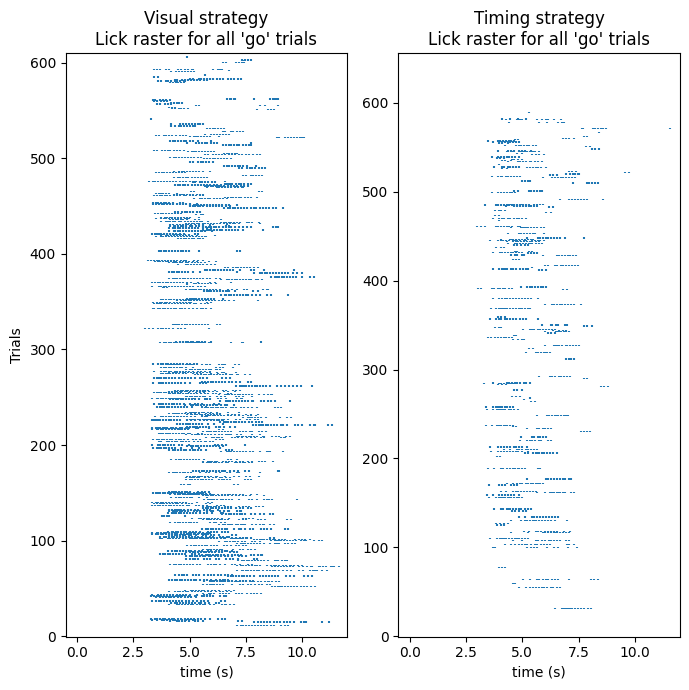

In [6]:
# plot licking patterns for each 'go' trial to get a sense of when they are failing to respond.

# Get lick times for each 'go' trial. Note: we subtract the trial start time so lick times are relative to trial start
lick_times_visual = trial_metadata_visual[trial_metadata_visual.go].lick_times.values - trial_metadata_visual[trial_metadata_visual.go].start_time.values
go_trials_visual =  trial_metadata_visual[trial_metadata_visual.go].index

lick_times_timing = trial_metadata_timing [trial_metadata_timing.go].lick_times.values - trial_metadata_timing[trial_metadata_timing.go].start_time.values
go_trials_timing =  trial_metadata_timing [trial_metadata_timing.go].index


# generate plot
fig, ax = plt.subplots(1, 2, figsize = (7, 7))
ax[0].eventplot(lick_times_visual, linelength = 1.5, lineoffsets = go_trials_visual);

# Add labels to plot
ax[0].set_ylim(-0.5, go_trials_visual[-1]+4)
ax[0].set_xlim(-0.5, 12)
ax[0].set_ylabel('Trials')
ax[0].set_xlabel('time (s)')
ax[0].set_title("Visual strategy\nLick raster for all 'go' trials")

ax[1].eventplot(lick_times_timing, linelength = 1.5, lineoffsets = go_trials_timing);

# Add labels to plot
ax[1].set_ylim(-0.5, go_trials_timing[-1]+4)
ax[1].set_xlim(-0.5, 12)
ax[1].set_xlabel('time (s)')
ax[1].set_title("Timing strategy\nLick raster for all 'go' trials")
plt.tight_layout()

In [7]:
# combine with stim-table to access information about pre-change presentations

def merge_dataframes(stim_table, trial_metadata):

    stim_table = stim_table[stim_table['active']] # get active session
    stim_table = stim_table[stim_table['trials_id'] != -1] # clean up 
    
    merged_df = trial_metadata.drop(columns=['lick_times']).merge(
        stim_table,
        left_index=True,         # Use the index of trial_metadata as the join key
        right_on='trials_id',    # Use the 'trials_id' column of stim_table as the join key
        how='outer',             # Default join type, adjust as needed
    )
    for col in trial_metadata.columns.intersection(stim_table.columns):
        merged_df[col] = merged_df[f"{col}_y"].combine_first(merged_df[f"{col}_x"])
        merged_df.drop(columns=[f"{col}_x", f"{col}_y"], inplace=True)

    merged_df = merged_df.rename(columns={'stop_time': 'trial_stop_time'})
    return merged_df

stim_table_v = session_visual.stimulus_presentations
stim_table_t = session_timing.stimulus_presentations

concat_table_v = merge_dataframes(stim_table_v, trial_metadata_visual)
concat_table_t = merge_dataframes(stim_table_t, trial_metadata_timing)


# Identify all prechange presentations
change_inds = concat_table_v[concat_table_v['is_change']].index.values
concat_table_v['is_prechange'] = False
concat_table_v.loc[change_inds-1, 'is_prechange'] = True

change_inds = concat_table_t[concat_table_t['is_change']].index.values
concat_table_t['is_prechange'] = False
concat_table_t.loc[change_inds-1, 'is_prechange'] = True

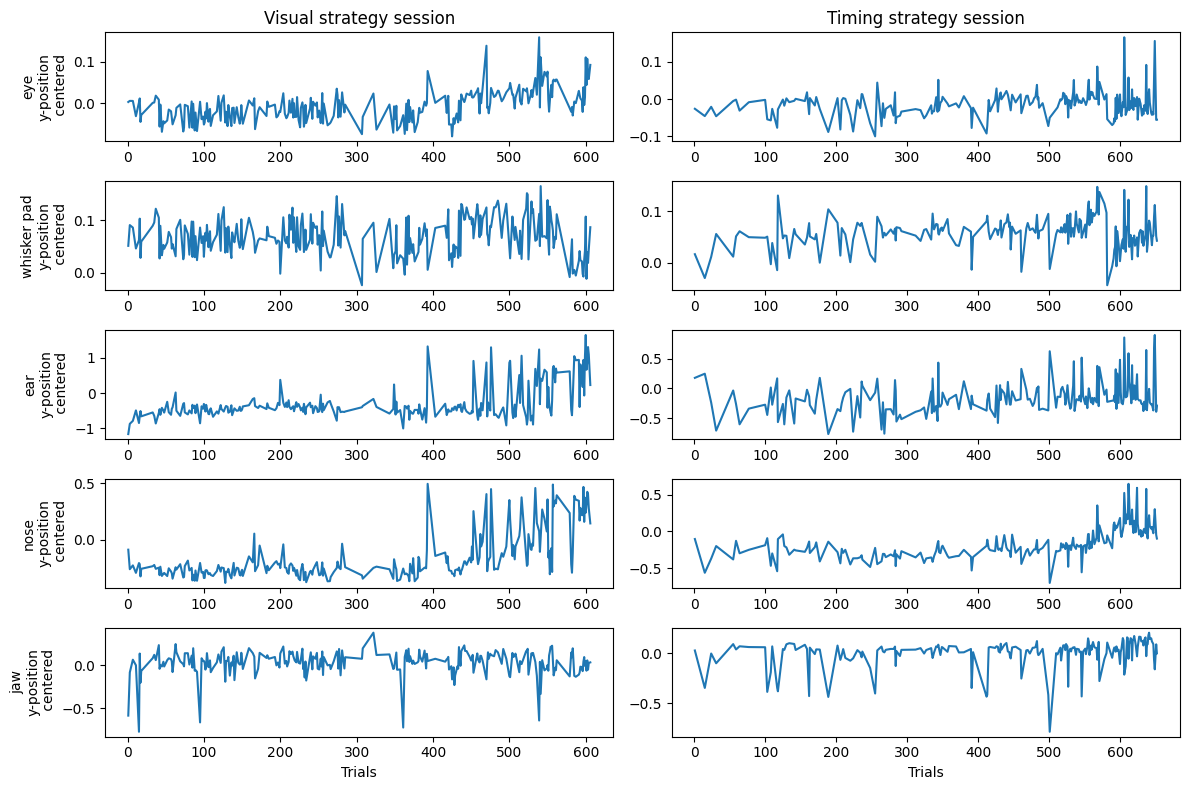

In [8]:
# facial expressions
from scipy.signal import savgol_filter

def part_info_LP(part_name, df, temp_norm):

    confidence = df[part_name , 'likelihood'].values.astype('float')
    x_c = df[part_name , 'x'].values.astype('float')
    y_c = df[part_name , 'y'].values.astype('float')
    xy_c = np.sqrt(x_c ** 2 + (492-y_c) ** 2)

    x_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    x = pd.Series(x_c).interpolate(limit_direction='both').to_numpy()
    
    y_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    y = 492 - pd.Series(y_c).interpolate(limit_direction='both').to_numpy()
    
    xy_c[(confidence < 0.99) | (temp_norm > np.nanmean(temp_norm) + 2 * np.nanstd(temp_norm))] = np.nan
    xy = pd.Series(xy_c).interpolate(limit_direction='both').to_numpy()
    
    # return savgol_filter(x, 11, 3), savgol_filter(y, 11, 3), savgol_filter(xy, 11, 3)
    return x, y, xy
    

pose_tracking_path = '/root/capsule/data/pose_tracking/outputs/video_preds/'
timestamps_path = '/root/capsule/data/VBN_video_timestamps/'

face_keys = ['eye_bottom_l','whisker_pad_l_side', 'ear_base_l', 'nose_tip', 'jaw']
part_names = ['eye', 'whisker pad', 'ear', 'nose', 'jaw']

# Read the CSV file
df_pose_tracking_v = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id_visual}*behavior.csv')[0], header=[0, 1, 2])
df_pose_tracking_v = df_pose_tracking_v.droplevel(0, axis=1)
temporal_norm_v = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id_visual}*norm.csv')[0])

df_pose_tracking_t = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id_timing}*behavior.csv')[0], header=[0, 1, 2])
df_pose_tracking_t = df_pose_tracking_t.droplevel(0, axis=1)
temporal_norm_t = pd.read_csv(glob.glob(f'{pose_tracking_path}/{session_id_timing}*norm.csv')[0])

# get timestamps for video
timestamps_v = np.load(glob.glob(f'{timestamps_path}/{session_id_visual}*side.npy')[0])
timestamps_t = np.load(glob.glob(f'{timestamps_path}/{session_id_timing}*side.npy')[0])

# Get timestamps corresponding to prechange trials
trial_start_v = concat_table_v[concat_table_v.is_prechange].start_time.values
trial_stop_v = concat_table_v[concat_table_v.is_change].start_time.values
pre_change_trials_v = concat_table_v[concat_table_v.is_prechange].trials_id.values

trial_start_t = concat_table_t[concat_table_t.is_prechange].start_time.values
trial_stop_t = concat_table_t[concat_table_t.is_change].start_time.values
pre_change_trials_t = concat_table_t[concat_table_t.is_prechange].trials_id.values
    
    
# Print the keys to check the new MultiIndex
fig, ax = plt.subplots(len(face_keys), 2, figsize = (12, 8))
for kno, key_name in enumerate(face_keys): 
    xv, yv, xyv = part_info_LP(key_name, df_pose_tracking_v, temporal_norm_v[key_name].values)
    xv, yv = xv*0.242, yv*0.242 # convert to mm
    xv = xv - np.nanmean(xv)
    yv = yv - np.nanmean(yv)
    
    xt, yt, xyv = part_info_LP(key_name, df_pose_tracking_t, temporal_norm_t[key_name].values)
    xt, yt = xt*0.242, yt*0.242 # convert to mm
    xt = xt - np.nanmean(xt)
    yt = yt - np.nanmean(yt)

    # Compute mean position in each go trial
    mean_key_position_v = [np.nanmean(yv[np.logical_and(s1 <= timestamps_v, timestamps_v <= s2)]) for s1, s2 in zip(trial_start_v, trial_stop_v)]
    mean_key_position_t = [np.nanmean(yt[np.logical_and(s1 <= timestamps_t, timestamps_t <= s2)]) for s1, s2 in zip(trial_start_t, trial_stop_t)]
    
    # pre-change
    ax[kno, 0].plot(pre_change_trials_v, mean_key_position_v)
    ax[kno, 1].plot(pre_change_trials_t, mean_key_position_t)
    ax[kno, 0].set_ylabel(f'{part_names[kno]}\ny-position\n centered')
ax[0, 0].set_title('Visual strategy session')
ax[0, 1].set_title('Timing strategy session')
ax[len(face_keys)-1, 0].set_xlabel('Trials')
ax[len(face_keys)-1, 1].set_xlabel('Trials')

plt.tight_layout()
plt.show()